<a href="https://colab.research.google.com/github/Mayurichavan065/decodelabs_Internship_tasks/blob/main/Project_2_EDA/Project_2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">Train a miniGPT language model with JAX AI stack</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">LoRA/QLoRA finetuning for LLM using Tunix</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Loading Hugging Face transformers checkpoints</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">8-bit integer quantisation in Keras</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Float8 training and inference with a simple transformer model</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">Pretraining a transformer from scratch with KerasHub</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Simple MNIST convnet</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Image classification from scratch using Keras 3</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">Image classification with KerasHub</a>


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the excel file into a DataFrame
df = pd.read_excel('/content/Raw_Data_Set.xlsx')


In [5]:
# Display the first 5 rows to make sure it looks right
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [6]:
df.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


In [7]:
# Check total missing values for each column
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [8]:
# Calculate standard boundaries for outliers using the IQR method on TotalPrice
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter and display the outliers
outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(f"Number of outliers detected: {len(outliers)}")
outliers[['OrderID', 'Product', 'Quantity', 'TotalPrice']].head()

Number of outliers detected: 8


,OrderID,Product,Quantity,TotalPrice
107,ORD200107,Printer,5,3353.75
326,ORD200326,Laptop,5,3352.40
328,ORD200328,Tablet,5,3370.20
469,ORD200469,Chair,5,3384.90
632,ORD200632,Laptop,5,3390.80


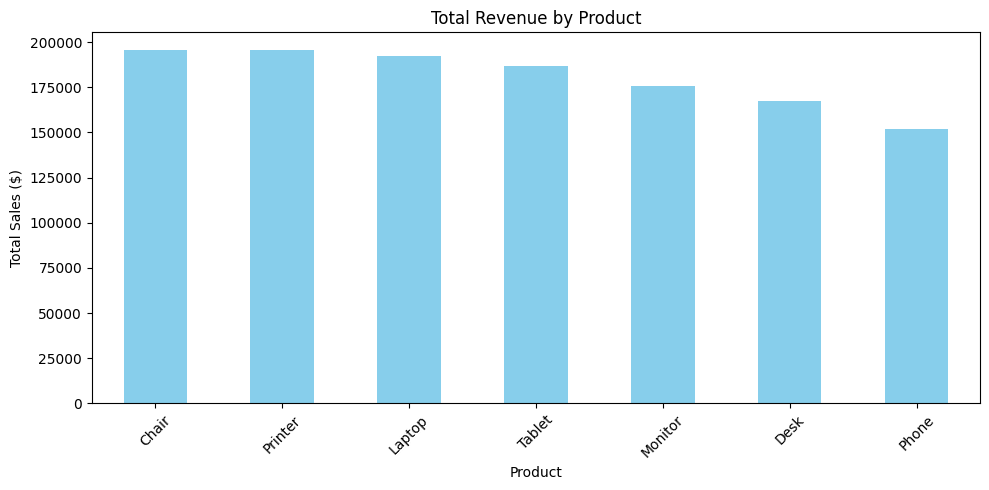

In [9]:
# Plot the total revenue generated by each product
plt.figure(figsize=(10, 5))
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()